In [1]:
import pandas as pd
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

if TotalCharges is a column of charge amounts (should be numbers), but pandas is reading it as str, that means somewhere in that column there's something that isn't a clean number — most commonly, blank spaces (" ") instead of an actual value. Pandas doesn't count a blank space as "null" — it's technically a valid string, just not a number — so  null-check missed it, but the dtype check caught it.

In [3]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


.describe() by default only summarizes numeric columns, and pandas doesn't think TotalCharges is numeric

In [4]:
df.notnull().sum()


customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64

In [5]:
df['TotalCharges'].str.strip().eq('').sum()

np.int64(11)

In [6]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [8]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60


In [9]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isnull().sum()  # should show 0 now

np.int64(0)

In [12]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [13]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [14]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

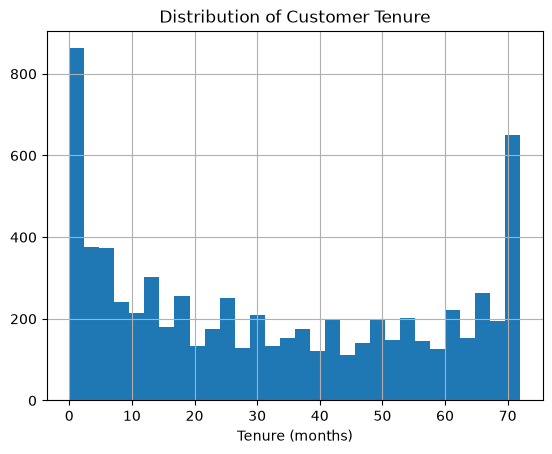

In [16]:
import matplotlib.pyplot as plt
df['tenure'].hist(bins=30)
plt.xlabel('Tenure (months)')
plt.title('Distribution of Customer Tenure')
plt.show()

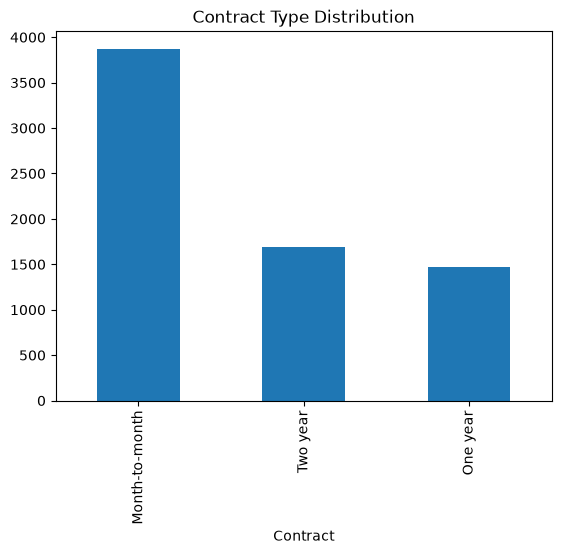

In [17]:
df['Contract'].value_counts().plot(kind='bar')
plt.title('Contract Type Distribution')
plt.show()

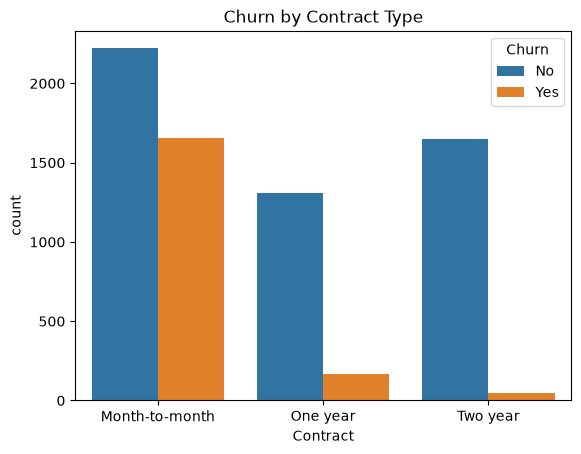

In [18]:
import seaborn as sns
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

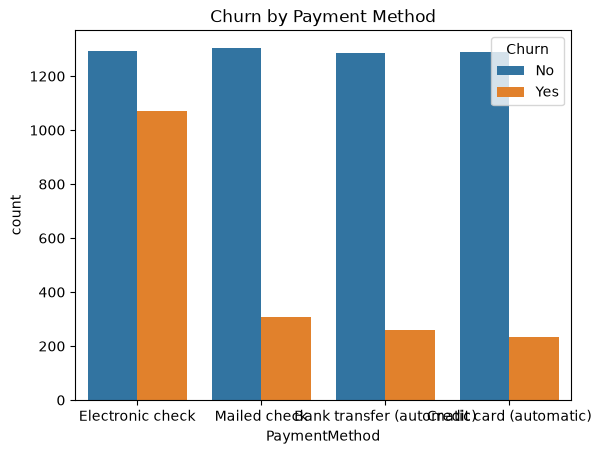

In [19]:
import seaborn as sns
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method')
plt.show()

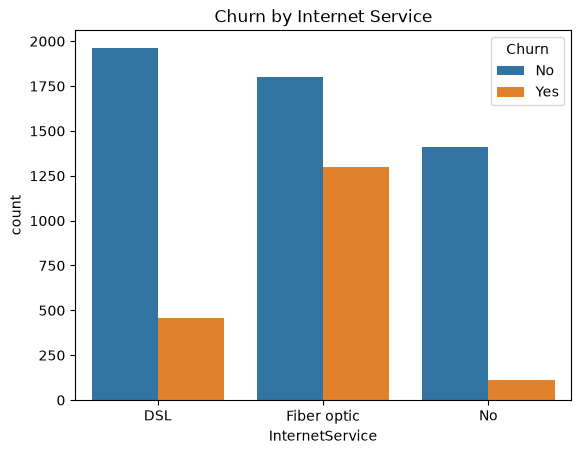

In [20]:
import seaborn as sns
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

### EDA Findings
- No missing data except TotalCharges (11 rows, tenure=0, filled with 0)
- Class imbalance in Churn: [your actual %] no-churn vs [your actual %] churn
- Features visually associated with higher churn: Month-to-month contract,
  Electronic check payment, Fiber optic internet
- These are correlations from EDA, not proven causal drivers — to be confirmed
  via feature importance after modeling

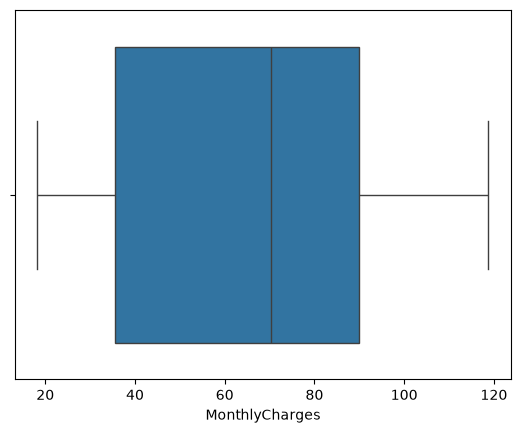

In [21]:
sns.boxplot(x=df['MonthlyCharges'])
plt.show()

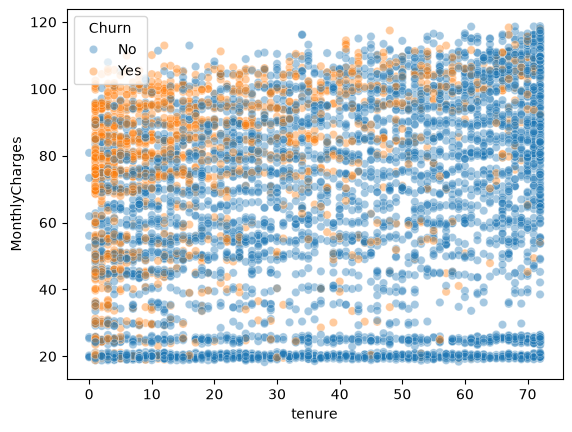

In [22]:
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4)
plt.show()

Scatter plot (tenure vs MonthlyCharges, colored by Churn):
- Churned customers cluster in low-tenure, high-monthly-charge region
- Confirms/converges with categorical findings (month-to-month contracts,
  fiber optic customers) — same underlying "new + expensive" risk profile
- Tenure appears to be the stronger visual driver of the two, to be confirmed
  via feature importance after modeling

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
for col in df.select_dtypes(include='object').columns:
    print(col, '→', df[col].unique())

customerID → <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender → <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner → <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents → <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService → <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines → <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService → <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity → <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup → <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection → <StringArray>
['No', 'Yes', 'No internet 

C:\Users\TIAA USER\AppData\Local\Temp\ipykernel_3404\3912604904.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [25]:
df = df.drop('customerID', axis=1)


In [26]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [27]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1})      
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No': 0, 'Yes': 1})
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [28]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [29]:
df=pd.get_dummies(df, columns=['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'], drop_first=True)

In [30]:
df.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

In [31]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [32]:
y = df['Churn']

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [36]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

In [37]:
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [38]:
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [39]:
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

In [40]:
y_train.value_counts(normalize=True)


Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [41]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [42]:
X_train[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


In [43]:
addon_yes_cols = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
                    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
X_train['TotalAddons'] = X_train[addon_yes_cols].sum(axis=1)
X_test['TotalAddons'] = X_test[addon_yes_cols].sum(axis=1)

In [44]:
X_train['TotalAddons'].value_counts()
X_train['TotalAddons'].describe()

count    5634.000000
mean        2.058040
std         1.854652
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: TotalAddons, dtype: float64

In [45]:
import pandas as pd
pd.concat([X_train['TotalAddons'], y_train], axis=1).groupby('TotalAddons')['Churn'].mean()

TotalAddons
0    0.209448
1    0.458225
2    0.361779
3    0.277966
4    0.230216
5    0.125000
6    0.046809
Name: Churn, dtype: float64

TotalAddons validation:
- Clear pattern for 1-6 addons: churn drops steadily as addon count rises
  (46% churn at 1 addon → 4.7% churn at 6 addons) — strong real signal
- Anomaly at 0 addons (20.9% churn, lower than 1-addon group) — likely because
  "0" mixes two different populations: customers who chose zero addons vs
  customers with no internet service at all (addons don't apply to them)
- Feature is validated as useful overall; potential future refinement:
  separate "no internet" from "internet but no addons chosen"

In [46]:
X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.256700,0.829698
MonthlyCharges,0.256700,1.000000,0.654117
TotalCharges,0.829698,0.654117,1.000000


In [47]:
X_train.dtypes.value_counts()

bool       21
int64       7
float64     3
Name: count, dtype: int64

In [48]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [49]:
X_train.dtypes.value_counts()

float64    31
Name: count, dtype: int64

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data.sort_values('VIF', ascending=False)

c:\Users\TIAA USER\ml-notebook\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
12,InternetService_No,inf
14,OnlineSecurity_Yes,inf
13,OnlineSecurity_No internet service,inf
18,DeviceProtection_Yes,inf
30,TotalAddons,inf
24,StreamingMovies_Yes,inf
23,StreamingMovies_No internet service,inf
22,StreamingTV_Yes,inf
21,StreamingTV_No internet service,inf
20,TechSupport_Yes,inf


In [51]:
redundant_cols = ['OnlineSecurity_No internet service', 'OnlineBackup_No internet service',
                   'DeviceProtection_No internet service', 'TechSupport_No internet service',
                   'StreamingTV_No internet service', 'StreamingMovies_No internet service']
X_train = X_train.drop(columns=redundant_cols)
X_test = X_test.drop(columns=redundant_cols)

In [52]:
addon_yes_cols = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
                    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
X_train = X_train.drop(columns=addon_yes_cols)
X_test = X_test.drop(columns=addon_yes_cols)

In [53]:
vif_data = pd.DataFrame()
vif_data['feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,feature,VIF
7,MonthlyCharges,136.313677
5,PhoneService,82.232452
18,TotalAddons,28.490965
9,MultipleLines_No phone service,27.939098
11,InternetService_Fiber optic,27.792297
12,InternetService_No,16.140330
8,TotalCharges,10.968804
4,tenure,7.627556
14,Contract_Two year,2.599085
10,MultipleLines_Yes,2.473648


In [54]:
X_train = X_train.drop(columns=['MultipleLines_No phone service'])
X_test = X_test.drop(columns=['MultipleLines_No phone service'])

In [55]:
X_train = X_train.drop(columns=['TotalCharges'])
X_test = X_test.drop(columns=['TotalCharges'])

In [56]:
vif_data = pd.DataFrame()
vif_data['feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,feature,VIF
7,MonthlyCharges,11.595051
5,PhoneService,9.707248
9,InternetService_Fiber optic,7.342117
16,TotalAddons,6.488581
10,InternetService_No,5.614565
12,Contract_Two year,3.392759
6,PaperlessBilling,2.861071
14,PaymentMethod_Electronic check,2.836946
2,Partner,2.800868
4,tenure,2.676890


Process:
1. Initial correlation check: tenure-TotalCharges (0.83), MonthlyCharges-TotalCharges (0.65)
2. First VIF run → inf values everywhere, revealed TWO hidden encoding-artifact traps:
   a) "No internet service" duplicated identically across 6 service columns
   b) TotalAddons double-counting its own raw component columns
3. Fixed both artifacts (dropped 6 redundant "No internet service" cols +
   6 raw addon _Yes cols, kept TotalAddons)
4. Second VIF run → surfaced a THIRD hidden artifact: MultipleLines_No phone service
   was redundant with PhoneService (same "impossible category" trap)
5. Dropped MultipleLines_No phone service and TotalCharges (the originally
   planned drop, now confirmed VIF ~11 pre-fix)
6. Final VIF run: all features under/near threshold. MonthlyCharges (11.6) is
   real business correlation (fiber optic genuinely costs more), not an artifact
   — left as-is, to be handled via regularization if Logistic Regression needs it

Key lesson: one-hot encoding categorical columns that share a "not applicable"
category (like "No internet service") creates PERFECT artificial multicollinearity
— always check for this pattern specifically, not just generic high correlation.

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [58]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [59]:
import numpy as np
import pandas as pd

coef_df = pd.DataFrame({'feature': X_train.columns, 'weight': model.coef_[0]})
coef_df['odds_ratio'] = np.exp(coef_df['weight'])
coef_df.sort_values('weight', ascending=False)

,feature,weight,odds_ratio
7,MonthlyCharges,1.795184,6.020584
10,InternetService_No,0.731346,2.077875
14,PaymentMethod_Electronic check,0.434945,1.544878
6,PaperlessBilling,0.367727,1.444448
1,SeniorCitizen,0.166729,1.181434
15,PaymentMethod_Mailed check,0.073113,1.075852
0,gender,0.045684,1.046744
2,Partner,0.018639,1.018814
8,MultipleLines_Yes,-0.000341,0.999660
13,PaymentMethod_Credit card (automatic),-0.017866,0.982293


In [60]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [61]:
y_pred_tree = tree_model.predict(X_test)
y_pred_proba_tree = tree_model.predict_proba(X_test)[:, 1]

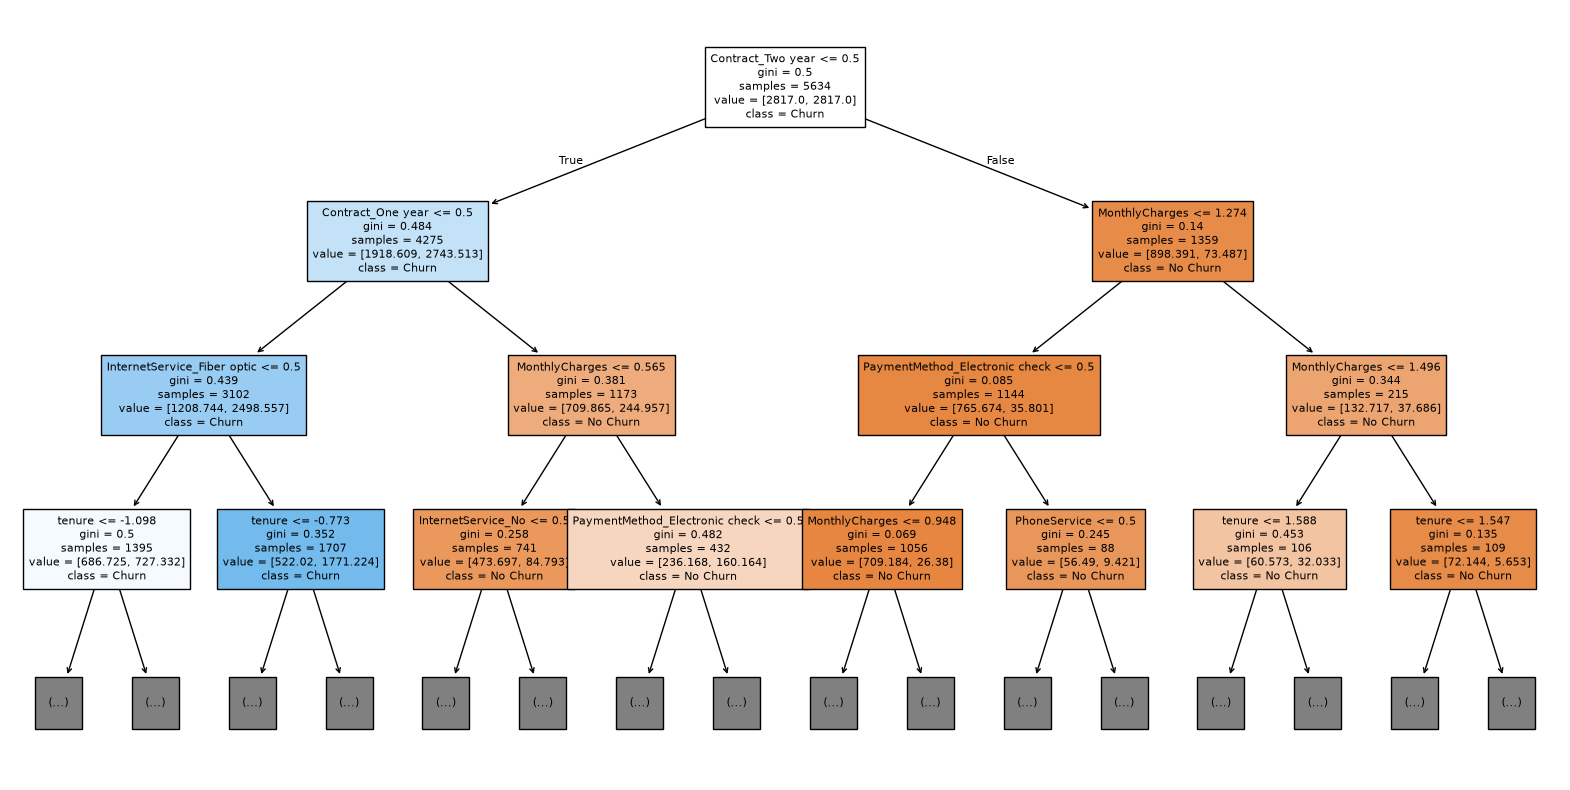

In [62]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X_train.columns, class_names=['No Churn','Churn'],
           filled=True, max_depth=3, fontsize=8)
plt.show()

In [63]:
import pandas as pd

gini_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'gini_importance': tree_model.feature_importances_
}).sort_values('gini_importance', ascending=False)

permutation importance in decision trees helps to understand importance of a feature by shuffling the values of a feature in the test set

In [64]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(tree_model, X_test, y_test, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

In [65]:
comparison = gini_importance_df.merge(perm_df, on='feature')
comparison.sort_values('gini_importance', ascending=False)

,feature,gini_importance,importance_mean,importance_std
0,Contract_Two year,0.406036,0.053371,0.005667
1,Contract_One year,0.253931,0.045067,0.008435
2,InternetService_Fiber optic,0.111769,0.026615,0.008877
3,tenure,0.102335,0.017814,0.003336
4,MonthlyCharges,0.066934,0.001207,0.001272
5,InternetService_No,0.020783,0.014833,0.002793
6,PaymentMethod_Electronic check,0.017203,0.002910,0.000976
7,PhoneService,0.014215,-0.003620,0.002568
8,gender,0.003945,0.000000,0.000000
9,Dependents,0.002070,-0.000284,0.000348


In [66]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=10,          # each tree can still be limited, though RF is more robust than a single tree
    max_features='sqrt',   # feature subset size per split
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

rf_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

In [67]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    reg_lambda=1,      # L2 regularization
    reg_alpha=0,       # L1 regularization
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),  # imbalance handling
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

In [68]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
        ('dt', DecisionTreeClassifier(max_depth=5, class_weight='balanced')),
        ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced'))
    ],
    voting='soft'
)
voting_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...max_iter=1000), DecisionTreeC..., max_depth=5), RandomForestC...ht='balanced')]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check','TotalAddons']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [69]:
rf_importance_df.head(10)


,feature,importance
4,tenure,0.236274
12,Contract_Two year,0.156872
7,MonthlyCharges,0.154351
9,InternetService_Fiber optic,0.094688
11,Contract_One year,0.074451
14,PaymentMethod_Electronic check,0.053305
16,TotalAddons,0.047988
10,InternetService_No,0.037717
6,PaperlessBilling,0.027825
0,gender,0.019435


In [70]:
xgb_importance_df.head(10)

,feature,importance
12,Contract_Two year,0.314740
11,Contract_One year,0.238198
10,InternetService_No,0.132348
9,InternetService_Fiber optic,0.112701
14,PaymentMethod_Electronic check,0.042601
4,tenure,0.041096
6,PaperlessBilling,0.020168
3,Dependents,0.013957
8,MultipleLines_Yes,0.013545
7,MonthlyCharges,0.012041


Feature importance across 4 models — synthesis:
- Universally agreed as important: Contract length, tenure (appear meaningfully
  in ALL four models)
- MonthlyCharges: highly important in Logistic Regression AND Random Forest,
  but nearly absent in XGBoost — likely due to XGBoost's sequential/greedy
  structure "using up" this correlated information via Contract at early trees
- Random Forest's random feature subsets naturally spread credit across
  correlated features more evenly than XGBoost's sequential greedy approach
- Conclusion: Contract type and tenure are the most ROBUSTLY important features
  (agreed across all 4 very different modeling approaches). MonthlyCharges'
  importance is real but model-architecture-dependent, due to its correlation
  with Contract/InternetService.


  Random Forest trees are built INDEPENDENTLY on different bootstrap samples with different random feature subsets — so across 100 different trees, sometimes tenure gets picked first, sometimes MonthlyCharges gets a chance to shine (because the "obviously best" feature, Contract, might not even be in that particular tree's random feature subset at a given split). This naturally SPREADS credit across genuinely correlated features more evenly.

XGBoost, by contrast, is SEQUENTIAL — the very first tree greedily grabs whatever gives the single best split (Contract), and once that's "used up" that information, subsequent trees are specifically hunting for what's LEFT OVER (residuals) — which increasingly won't include much more from already-correlated features like MonthlyCharges, since Contract already captured most of that shared signal early and decisively.

In [71]:
from sklearn.metrics import (confusion_matrix, classification_report,
                               accuracy_score, precision_score, recall_score, f1_score)

# Universal starting point for evaluating any classifier
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1: {f1_score(y_test, y_pred):.3f}")

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

Accuracy: 0.737
Precision: 0.503
Recall: 0.775
F1: 0.611


In [72]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_tree, target_names=['No Churn','Churn']))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn','Churn']))

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn','Churn'])) is y_pred_xgb

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

=== Decision Tree ===
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
we

False

Model comparison (Section 5.1 findings):
- All 4 models perform similarly overall (F1: 0.61-0.62) — suggests we're near
  the ceiling of what's predictable from these features, not that one algorithm
  is clearly superior
- Prioritizing RECALL (business rationale: missing a churner costs more than an
  unnecessary retention offer) → XGBoost is the standout, catching 81% of actual
  churners vs 77-78% for the other three models
- Precision is fairly low across all models (~50-52%) — roughly half of flagged
  "at risk" customers are false alarms. Acceptable if retention intervention is
  low-cost (e.g. an email); would need reconsideration if intervention is
  expensive (e.g. personal account manager calls)
- RECOMMENDATION: XGBoost, given the recall priority and comparable precision
  to alternatives

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

In [74]:
auc = roc_auc_score(y_test, y_pred_proba)

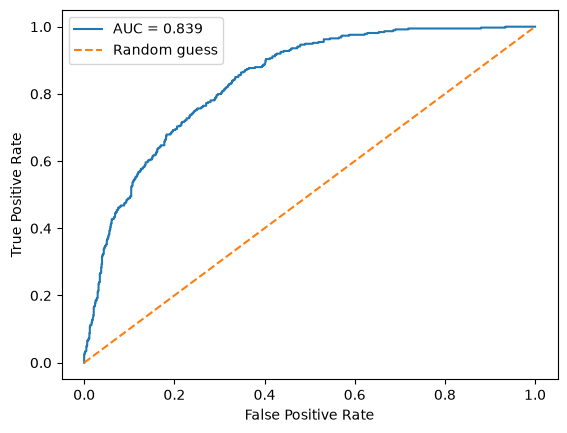

In [75]:
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

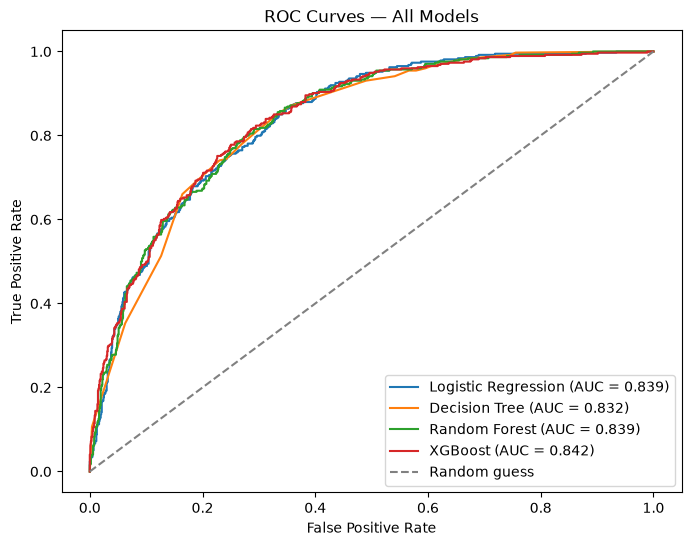

In [76]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models_proba = {
    'Logistic Regression': y_pred_proba,
    'Decision Tree': y_pred_proba_tree,
    'Random Forest': y_pred_proba_rf,
    'XGBoost': y_pred_proba_xgb
}

plt.figure(figsize=(8,6))
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.show()

In [77]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')

print(scores)          # all 5 individual scores
print(scores.mean())   # average
print(scores.std())    # stability check

[0.84455431 0.82516601 0.83779264 0.85904505 0.84973693]
0.8432589883687983
0.011402437618806098


In [78]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

Logistic Regression: Mean=0.8433, Std=0.0114
Decision Tree: Mean=0.8241, Std=0.0091
Random Forest: Mean=0.8394, Std=0.0111
XGBoost: Mean=0.8463, Std=0.0121


Cross-validation findings 
- Decision Tree is RELIABLY the weakest model (ranges barely overlap with others)
  — expected, since it lacks bagging's variance reduction or boosting's bias
  reduction that the other three benefit from
- Logistic Regression, Random Forest, and XGBoost are STATISTICALLY
  INDISTINGUISHABLE on this dataset — their cross-validated AUC ranges overlap
  substantially (0.83-0.86 roughly, for all three)
- XGBoost has the highest MEAN, but the gap is within normal fold-to-fold noise,
  not a reliable, provable advantage
- REVISED CONCLUSION: rather than declaring XGBoost the definitive winner, the
  honest finding is that model choice among these three matters less than
  feature quality/engineering for this dataset. Final model selection could
  reasonably favor XGBoost (highest mean, and better recall from Section 5.1)
  OR Logistic Regression (simpler, more interpretable, nearly identical
  performance) — a legitimate business/interpretability tradeoff, not a
  clear-cut accuracy decision

In [80]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import xgboost as xgb

param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'reg_lambda': [0.1, 1, 5, 10],
    'reg_alpha': [0, 0.1, 1, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=skf,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)

Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best CV AUC: 0.8474412260922822


FINAL MODEL SELECTION 
- Compared 4 models: Logistic Regression, Decision Tree, Random Forest, XGBoost
- Cross-validated AUC: LogReg 0.843, Decision Tree 0.824, Random Forest 0.839,
  XGBoost 0.846 (default) → 0.847 (tuned)
- Decision Tree reliably weakest (non-overlapping range); LogReg, RF, XGBoost
  statistically indistinguishable
- Hyperparameter tuning yielded negligible improvement (+0.001), confirming
  performance is bounded by feature signal, not model/tuning choice
- RECOMMENDATION: XGBoost (tuned) — highest mean AUC, best recall (0.81,
  prioritized per business reasoning: missing a churner costs more than an
  unneccessary retention offer), though the practical difference vs simpler
  Logistic Regression is small enough that interpretability needs could
  reasonably justify choosing LogReg instead
- Key business insight: churn strongly associated with month-to-month
  contracts, high monthly charges, low tenure, fiber optic internet, and
  electronic check payment — a "new + expensive + uncommitted" risk profile